#Les imports

In [59]:
!pip install pyarrow

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

colors = pd.read_parquet("auto_color.parquet")
choix = pd.read_parquet("choix_vehicule.parquet")

#Nettoyage

In [60]:
colors.isna().sum()
choix.isna().sum()

,0
annee,0
mois,0
civilite,0
departement,0
brand,0
modele,0
energie,0
usage,0
boite_de_vitesse,0
presentation_video,0


In [61]:
len(choix)

211468

In [62]:
colors['Effet'].unique()

array(['Nacré, Opaque', 'Opaque', 'Xyrallic, Opaque',
       'Nacré, Métallisé, Opaque', 'Métallisé, Opaque',
       'Xyrallic, Nacré, Opaque', 'Xyrallic, Métallisé, Opaque',
       'Xyrallic, Nacré, Métallisé, Opaque', None, 'Métallisé', 'Nacré'],
      dtype=object)

In [63]:
colors['Type de peinture'].unique()

array(['Base mate à revernir bicouche', 'Brillant direct',
       'Peinture texturée Raptor', 'Base mate à revernir tricouche', None],
      dtype=object)

In [64]:
Ncolors = colors.drop(columns=['Catégorie', 'Type de peinture', 'Element de carrosserie', 'Code de couleur', 'Couleur apprêt', 'Variante','Système'])
Nchoix = choix.drop(columns=['usage', 'presentation_video', 'reprise_energie', 'reprise_annee', 'reprise_modele', 'kms_min','kms_max', 'kms_reprise', 'modele_concurrence', 'marque_concurrence'])

In [65]:
Nchoix.head()

,annee,mois,civilite,departement,brand,modele,energie,boite_de_vitesse,reprise_marque,reprise_couleur
index,,,,,,,,,,
0,2023,11,monsieur,92,AUDI,Q3 tfsie,hybride,robotisée,reprise_non,NC
1,2023,11,monsieur,77,AUDI,Q4 e-tron,électrique,robotisée,Citroën,NC
2,2023,11,monsieur,92,Volkswagen,Polo,essence,robotisée,reprise_non,NC
3,2023,11,monsieur,83,CUPRA,Born 204 ch batterie l,électrique,robotisée,reprise_non,NC
4,2023,11,madame,57,Volkswagen,T-roc,essence,mecanique,reprise_non,NC


In [66]:
#Permet de retirer les valeurs NC de la colonne reprise_couleur du jeu de donnée Nchoix
Nchoix = Nchoix[
    Nchoix['reprise_couleur'].str.strip().str.upper() != 'NC'
]

In [67]:
#Permet de retirer les marques chiffrés
#Nchoix = Nchoix[
 #   Nchoix['brand'].notna() &
  #  ~Nchoix['brand'].str.strip().str.fullmatch(r'\d+')
#]

In [68]:
len(Nchoix)

5640

In [69]:

"""ids_a_verifier = [
    '25091010376082', '25382330714770', '26835333024274',
    '26881567913874', '27006279306642', '28121657398034',
    '29481365320082', '29576441776146', '29577564225426',
    '29577629036690'
]

print("--- Inspection des modèles par ID ---")
for id_auto in ids_a_verifier:
    if id_auto in marques.index:
        print(f"ID {id_auto} contient : {marques[id_auto]}")
    else:
        print(f"ID {id_auto} non trouvé dans le dataset.")
"""


'ids_a_verifier = [\n    \'25091010376082\', \'25382330714770\', \'26835333024274\',\n    \'26881567913874\', \'27006279306642\', \'28121657398034\',\n    \'29481365320082\', \'29576441776146\', \'29577564225426\',\n    \'29577629036690\'\n]\n\nprint("--- Inspection des modèles par ID ---")\nfor id_auto in ids_a_verifier:\n    if id_auto in marques.index:\n        print(f"ID {id_auto} contient : {marques[id_auto]}")\n    else:\n        print(f"ID {id_auto} non trouvé dans le dataset.")\n'

In [70]:
mask_stellantis = (Nchoix['brand'] == '27006279306642')

Nchoix['brand'] = np.where(
    mask_stellantis & Nchoix['modele'].str.contains('^2|^3|^4|^5', regex=True),
    'Peugeot',
    np.where(
        mask_stellantis & Nchoix['modele'].str.contains('^C3', case=False, regex=True),
        'Citroen',
        Nchoix['brand']
    )
)
masque_id = (Nchoix['brand'] == '26835333024274')

Nchoix['brand'] = np.where(
    masque_id & Nchoix['modele'].str.contains('ypsilon', case=False),
    'Lancia',
    np.where(
        masque_id & Nchoix['modele'].str.contains('audi|q2', case=False),
        'Audi',
        Nchoix['brand']
    )
)

mapping_marques = {
    'Audi AGC': 'AUDI',
    'LeadGen Mitsubishi': 'Mitsubishi',
    'Lexus WCB': 'LEXUS',
    'Nissan Lead Gen': 'Nissan',
    'Renault Annalect': 'Renault',
    'Vidéo Live Volkswagen': 'Volkswagen',
    'Mercedes-benz': 'Mercedes',
    'Mercedes-Benz': 'Mercedes',
    'VW Utilitaires':'VWU',
    'Alpine France': 'Alpine',
    '25091010376082':'Honda',
    '25382330714770':'AUDI',
    '26881567913874':'Hyundai',
        '28121657398034':'Skoda',
     '29481365320082':'Volkswagen',
    '29576441776146':'VWU',
    '29577564225426':'Seat',
    '29577629036690':'CUPRA',
    'Audi':'AUDI',
    'Mercedes-Benz ': 'Mercedes'
}

Nchoix['brand']=Nchoix['brand'].replace(mapping_marques)

Nchoix = Nchoix[Nchoix['brand']!= 'Test E Car']



In [71]:
len(Nchoix)

5640

In [72]:
Nchoix['brand'].unique()

array(['Citroen', 'Hyundai', 'Seat', 'Skoda', 'Volkswagen', 'CUPRA',
       'OPEL', 'Dacia', 'Renault', 'DS', 'VWU', 'AUDI', 'Fiat', 'Peugeot',
       'KIA', 'AlfaRomeo', 'Honda', 'Lancia', 'Toyota'], dtype=object)

In [89]:
Nchoix = Nchoix[
    Nchoix['departement'].str.fullmatch(r'\d{2}')
]

In [90]:
len(Nchoix)32


5637

#Analyse Statistique Descriptive

In [ ]:
Ncolors['Nom'].value_counts()

In [ ]:
Ncolors['Nom'].value_counts(normalize=True) * 100

In [ ]:
Ncolors['Marque'].value_counts()

In [ ]:
Ncolors['Marque'].value_counts(normalize=True) * 100

In [ ]:
Ncolors['Couleur dominante'].value_counts()

In [ ]:
Ncolors['Couleur dominante'].value_counts(normalize=True) * 100


In [ ]:
Ncolors['Effet'].value_counts()

In [ ]:
Ncolors['Effet'].value_counts(normalize=True) * 100

In [ ]:
Ncolors['Année debut'].value_counts()

In [ ]:
Ncolors['Année fin'].value_counts()

In [21]:
fig = px.bar(Ncolors['Nom'].value_counts().reset_index(),
             x='Nom', y='count',
             title="Distribution des couleurs")
fig.show()

In [22]:
Ncolors.groupby(['Marque', 'Nom']).size().reset_index(name='count')

,Marque,Nom,count
0,Alfa Romeo,Alabastro,9
1,Alfa Romeo,Azzurro Cristallo,6
2,Alfa Romeo,Bianco Conchiglia,6
3,Alfa Romeo,Bianco Dorato,8
4,Alfa Romeo,Bianco Elegante,24
...,...,...,...
2944,Volvo,White Gold,2
2945,Volvo,White Pearl,8
2946,Volvo,White Silver,1
2947,Volvo,Willow Green,32


In [23]:
pd.crosstab(Ncolors['Marque'], Ncolors['Nom'], normalize = 'index')

Nom,AA-Yellow,Absinthe,Abysse Camaieu,Acapulcoblau,Acidgruen,Acqua Marine,Admiral Blue,Adriablau,Aeroblau,Agave Gruen,...,Yas Marina Blu,Yellow,Yellow Lacerta,Yellow Sole,York Blue,Zafferano Orange,Zanzibar Gold,Zeal Red,Zederngruen,Zitrusgelb
Marque,,,,,,,,,,,,,,,,,,,,,
Alfa Romeo,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Audi,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.001091,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001091,0.002183
Bmw,0.000000,0.0000,0.0000,0.000000,0.002434,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.001622,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Citroen,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Dacia,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fiat,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.001589,0.000477,0.002861,0.000000,0.000477,0.000000,0.000000,0.000000,0.000000
Mazda,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005224,0.000000,0.000000
Peugeot,0.000000,0.0000,0.0000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.001413,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Renault,0.000000,0.0012,0.0004,0.000000,0.000000,0.0008,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [24]:
Ncolors.groupby(['Année debut', 'Nom']).size().reset_index(name='count')

,Année debut,Nom,count
0,2000.0,Acidgruen,9
1,2000.0,Agave Gruen,15
2,2000.0,Amarelo Correio,12
3,2000.0,Amarelo Imola,9
4,2000.0,Amarillo Yo-Yo,3
...,...,...,...
2962,2018.0,BC Gold,2
2963,2018.0,Bleu Quasar,1
2964,2018.0,Blue Quasar,1
2965,2018.0,Deep Blue,1


<Axes: xlabel='Année debut'>

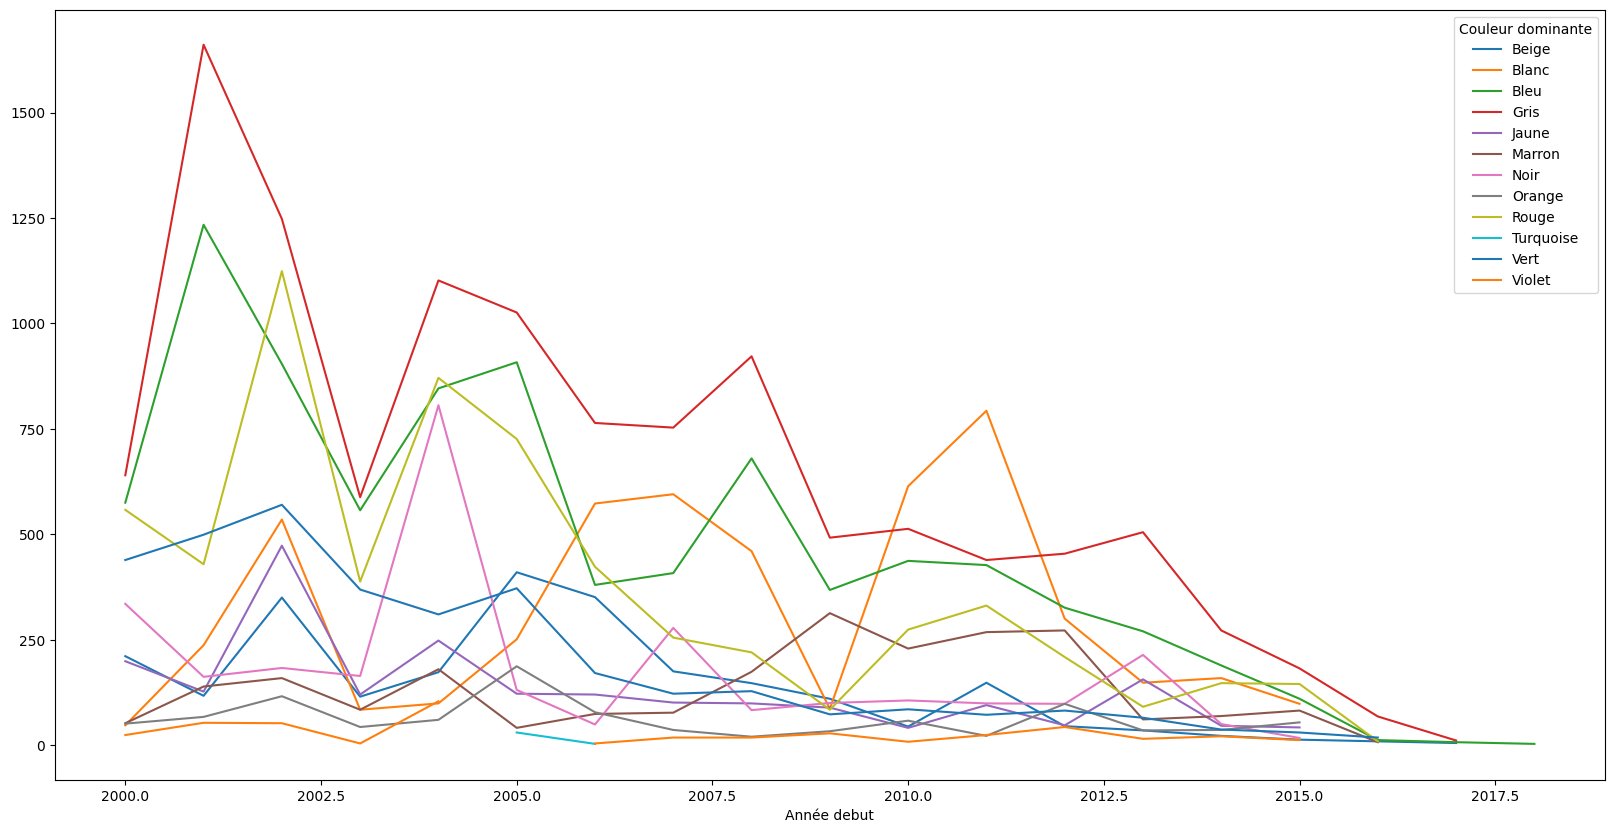

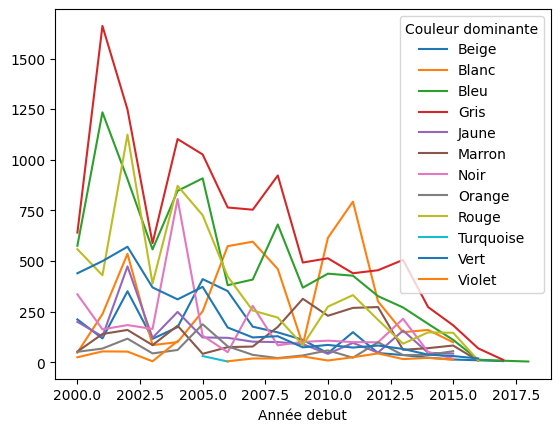

In [25]:
#Analyse temporelles, Couleur des voitures dans le temps
pivot = Ncolors.groupby(['Année debut', 'Couleur dominante']).size().unstack()

pivot.plot(figsize=(20, 10))
pivot.plot()

In [26]:
#Distribution des couleurs
fig = px.bar(Ncolors['Couleur dominante'].value_counts().reset_index(),
             x='Couleur dominante', y='count',
             title="Distribution des couleurs")
fig.show()

In [27]:
Nchoix['brand'].unique()

array(['Citroen', 'Hyundai', 'Seat', 'Skoda', 'Volkswagen', 'CUPRA',
       'OPEL', 'Dacia', 'Renault Annalect', 'DS', 'VW Utilitaires',
       'AUDI', 'Fiat', '27006279306642', 'KIA', 'AlfaRomeo', 'Honda',
       '26835333024274', 'Toyota'], dtype=object)

In [28]:
def cramers_v(x, y):

    data = pd.DataFrame({'x': x, 'y': y}).dropna()

    confusion_matrix = pd.crosstab(data['x'], data['y'])

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))


def cramers_v_matrix(df, columns):

    results = []

    for col in columns:
        if col != 'color':
            score = cramers_v(df['Couleur dominante'], df[col])
            results.append((col, score))

    return pd.DataFrame(results, columns=['variable', 'cramers_v']) \
             .sort_values(by='cramers_v', ascending=False)

cols = ['Marque', 'Modèle', 'Effet', 'Année debut', 'Année fin']
cramers_v_matrix(Ncolors, cols)

,variable,cramers_v
2,Effet,0.246172
1,Modèle,0.220630
4,Année fin,0.152969
3,Année debut,0.145389
0,Marque,0.103265


In [29]:
Ncolors_results = pd.DataFrame({
    'variable': ['Effet', 'Modèle', 'Année fin', 'Année debut', 'Marque'],
    'cramers_v': [0.246172, 0.220630, 0.152969, 0.145389, 0.103265]
})

In [30]:
#Influence des variables sur le choix de couleur
fig = px.bar(
    Ncolors_results.sort_values(by='cramers_v'),
    x='cramers_v',
    y='variable',
    orientation='h',
    title="Influence des variables sur le choix de couleur"
)

fig.show()

In [31]:
Ncolors.groupby(['Marque', 'Modèle', 'Couleur dominante']).size().reset_index(name='count')

,Marque,Modèle,Couleur dominante,count
0,Alfa Romeo,147,Beige,10
1,Alfa Romeo,147,Blanc,14
2,Alfa Romeo,147,Bleu,11
3,Alfa Romeo,147,Rouge,25
4,Alfa Romeo,147,Vert,12
...,...,...,...,...
2713,Volvo,XC90,Bleu,3
2714,Volvo,XC90,Gris,5
2715,Volvo,XC90,Marron,2
2716,Volvo,XC90,Noir,1


In [32]:
Ncolors.head()

,Marque,Modèle,Nom,Effet,Couleur dominante,Année debut,Année fin
0,Citroen,C3,Bleu Oriental,"Nacré, Opaque",Bleu,2002.0,2009.0
1,Citroen,Citroen,Jaune Soleil,Opaque,Jaune,2002.0,2003.0
2,Citroen,C4 Picasso,Show Rouge,"Xyrallic, Opaque",Rouge,2006.0,2012.0
3,Citroen,Jumper,Branco Banquise,Opaque,Blanc,2002.0,2008.0
4,Citroen,DS3,Gold Matt,"Nacré, Métallisé, Opaque",Beige,2013.0,2014.0


In [33]:
#Répartition des couleur par marques
fig = px.histogram(
    Ncolors,
    x='Marque',
    color='Couleur dominante',
    title="Répartition des couleurs par marque"
)

fig.show()

In [34]:
#Répartition des couleurs par rapport aux différents modèles
fig = px.histogram(
    Ncolors,
    x='Modèle',
    color='Couleur dominante',
    title="Couleurs par modèle"
)

fig.show()

In [35]:
#Répartition des couleurs par modèle (top 10)
top_models = Ncolors['Modèle'].value_counts().head(10).index

df_filtered = Ncolors[Ncolors['Modèle'].isin(top_models)]

fig = px.histogram(
    df_filtered,
    x='Modèle',
    color='Couleur dominante',
    title="Couleurs par modèle (Top 10)"
)

fig.show()

In [36]:
#Répartition des couleurs par rapport aux effets
fig = px.histogram(
    Ncolors,
    x='Effet',
    color='Couleur dominante',
    title="Relation Effet - Couleur"
)

fig.show()

In [37]:
Ncolors['Année debut'] = Ncolors['Année debut'].astype(int)

pivot = Ncolors.groupby(['Année debut', 'Couleur dominante']).size().reset_index(name='count')

fig = px.line(
    pivot,
    x='Année debut',
    y='count',
    color='Couleur dominante',
    title="Évolution des couleurs dans le temps"
)

fig.show()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

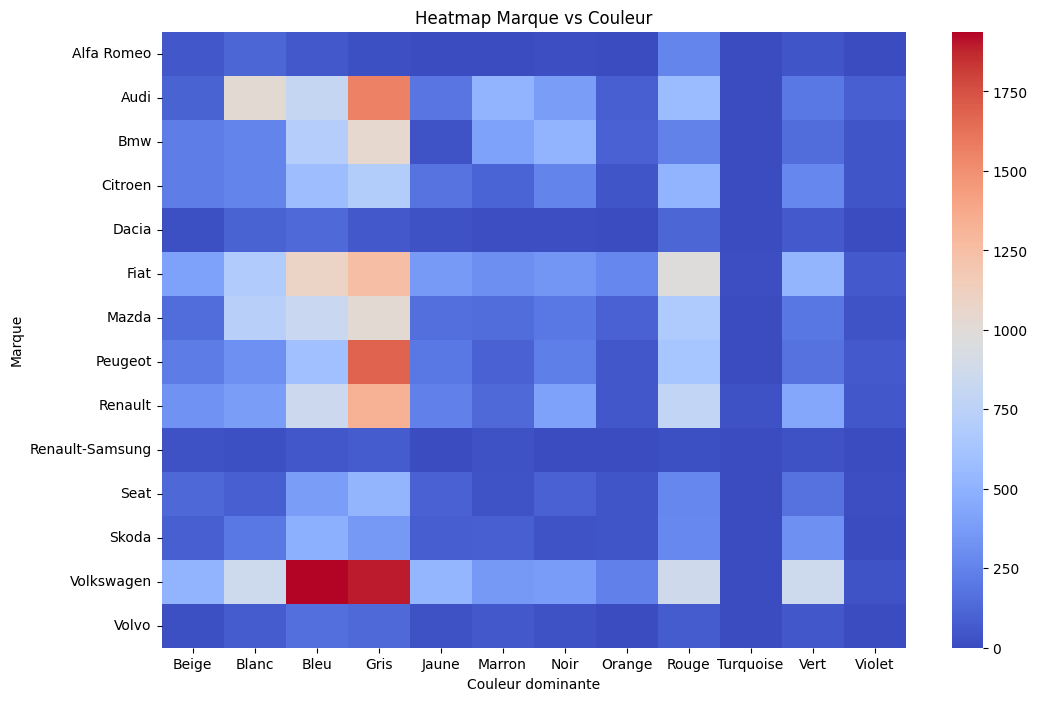

In [38]:
table = pd.crosstab(Ncolors['Marque'], Ncolors['Couleur dominante'])

plt.figure(figsize=(12,8))
sns.heatmap(table, cmap="coolwarm")
plt.title("Heatmap Marque vs Couleur")
plt.show()

In [39]:
fig = px.scatter(
    Ncolors,
    x='Année debut',
    y='Année fin',
    color='Couleur dominante',
    size=Ncolors.groupby('Couleur dominante')['Couleur dominante'].transform('count'),
    title="Cycle de vie des couleurs"
)

fig.show()

In [40]:
import pandas as pd
import plotly.graph_objects as go

# 🔹 Filtrer pour garder un graphique lisible
top_brands = Ncolors['Marque'].value_counts().head(5).index
top_models = Ncolors['Modèle'].value_counts().head(10).index
top_colors = Ncolors['Couleur dominante'].value_counts().head(10).index

df_filtered = Ncolors[
    (Ncolors['Marque'].isin(top_brands)) &
    (Ncolors['Modèle'].isin(top_models)) &
    (Ncolors['Couleur dominante'].isin(top_colors))
]

# 🔹 Créer les flux (Marque → Modèle)
flow_1 = df_filtered.groupby(['Marque', 'Modèle']).size().reset_index(name='count')

# 🔹 Créer les flux (Modèle → Couleur)
flow_2 = df_filtered.groupby(['Modèle', 'Couleur dominante']).size().reset_index(name='count')

# 🔹 Créer la liste des noeuds
labels = list(pd.concat([
    flow_1['Marque'],
    flow_1['Modèle'],
    flow_2['Couleur dominante']
]).unique())

# 🔹 Mapping label → index
label_to_index = {label: i for i, label in enumerate(labels)}

# 🔹 Créer les liens
source = []
target = []
value = []

# Marque → Modèle
for _, row in flow_1.iterrows():
    source.append(label_to_index[row['Marque']])
    target.append(label_to_index[row['Modèle']])
    value.append(row['count'])

# Modèle → Couleur
for _, row in flow_2.iterrows():
    source.append(label_to_index[row['Modèle']])
    target.append(label_to_index[row['Couleur dominante']])
    value.append(row['count'])

# 🔹 Sankey
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(title_text="Flux Marque → Modèle → Couleur", font_size=12)
fig.show()

#Test de corrélation

In [41]:
Nchoix.head()

,annee,mois,civilite,departement,brand,modele,energie,boite_de_vitesse,reprise_marque,reprise_couleur
index,,,,,,,,,,
2999,2023,11,monsieur,93,Citroen,C3a,essence,robotisée,Volkswagen,gris
2,2024,8,monsieur,64,Citroen,C3a,essence,robotisée,Citroën,blanc
24,2024,8,monsieur,27,Citroen,C3,essence,robotisée,Peugeot,vert
74,2024,8,madame,73,Citroen,C3,essence,robotisée,autre_marque,rouge
128,2024,8,monsieur,27,Citroen,Ami,essence,robotisée,Peugeot,bleu


In [42]:
def cramers_v_matrix(df, columns):

    results = []

    for col in columns:
        if col != 'color':
            score = cramers_v(Nchoix['reprise_couleur'], df[col])
            results.append((col, score))

    return pd.DataFrame(results, columns=['variable', 'cramers_v']) \
             .sort_values(by='cramers_v', ascending=False)

cols = ['annee', 'mois', 'civilite', 'departement', 'brand', 'modele', 'energie', 'boite_de_vitesse']
df_results = cramers_v_matrix(Nchoix, cols)

In [43]:
fig = px.bar(
    df_results.sort_values(by='cramers_v'),
    x='cramers_v',
    y='variable',
    orientation='h',
    text='cramers_v',
    title="Influence des variables sur le choix de couleur"
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.show()

In [44]:
Nchoix['annee'] = pd.to_numeric(Nchoix['annee'], errors='coerce')

pivot = Nchoix.groupby(['annee', 'reprise_couleur']) \
          .size() \
          .reset_index(name='count')

In [45]:
fig = px.line(
    pivot,
    x='annee',
    y='count',
    color='reprise_couleur',
    title="Évolution des préférences de couleurs dans le temps"
)

fig.show()

In [46]:
Nchoix['reprise_couleur'].unique()

array(['gris', 'blanc', 'vert', 'rouge', 'bleu', 'noir', 'orange',
       'jaune', 'marron', 'beige', 'violet', 'rose'], dtype=object)

In [47]:
Nchoix['brand'].unique()

array(['Citroen', 'Hyundai', 'Seat', 'Skoda', 'Volkswagen', 'CUPRA',
       'OPEL', 'Dacia', 'Renault Annalect', 'DS', 'VW Utilitaires',
       'AUDI', 'Fiat', '27006279306642', 'KIA', 'AlfaRomeo', 'Honda',
       '26835333024274', 'Toyota'], dtype=object)

In [73]:
pd.crosstab(
    Nchoix['departement'],
    Nchoix['reprise_couleur'],
    normalize='index'
)

reprise_couleur,beige,blanc,bleu,gris,jaune,marron,noir,orange,rose,rouge,vert,violet
departement,,,,,,,,,,,,
01,0.086957,0.130435,0.195652,0.304348,0.000000,0.065217,0.173913,0.043478,0.0,0.000000,0.000000,0.000000
02,0.000000,0.500000,0.068182,0.159091,0.022727,0.000000,0.090909,0.045455,0.0,0.000000,0.090909,0.022727
03,0.000000,0.038462,0.115385,0.384615,0.000000,0.000000,0.307692,0.000000,0.0,0.153846,0.000000,0.000000
04,0.000000,0.086957,0.043478,0.478261,0.043478,0.000000,0.260870,0.000000,0.0,0.000000,0.086957,0.000000
05,0.000000,0.142857,0.000000,0.500000,0.000000,0.000000,0.214286,0.000000,0.0,0.000000,0.142857,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
92,0.026786,0.017857,0.125000,0.455357,0.000000,0.071429,0.178571,0.017857,0.0,0.053571,0.053571,0.000000
93,0.038095,0.090476,0.142857,0.395238,0.000000,0.019048,0.204762,0.000000,0.0,0.085714,0.004762,0.019048
94,0.006494,0.116883,0.090909,0.454545,0.000000,0.019481,0.240260,0.000000,0.0,0.038961,0.025974,0.006494


In [79]:
top_dep = Nchoix['departement'].value_counts().head(10).index

df_filtered = Nchoix[Nchoix['departement'].isin(top_dep)]

import plotly.express as px

fig = px.histogram(
    df_filtered,
    x='departement',
    color='reprise_couleur',
    title="Répartition des couleurs par département (Top 10)"
)

fig.show()

In [80]:
pd.crosstab(
    Nchoix['annee'],
    Nchoix['reprise_couleur'],
    normalize='index'
)

reprise_couleur,beige,blanc,bleu,gris,jaune,marron,noir,orange,rose,rouge,vert,violet
annee,,,,,,,,,,,,
2023,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024,0.025201,0.174799,0.099732,0.347989,0.009115,0.031099,0.208043,0.008043,0.000000,0.058981,0.034316,0.002681
2025,0.023582,0.179120,0.096714,0.363275,0.005564,0.034711,0.193959,0.006094,0.002385,0.062533,0.029677,0.002385


In [81]:
top_dep = Nchoix['annee'].value_counts().head(10).index

df_filtered = Nchoix[Nchoix['annee'].isin(top_dep)]

import plotly.express as px

fig = px.histogram(
    df_filtered,
    x='annee',
    color='reprise_couleur',
    title="Répartition des couleurs par département (Top 10)"
)

fig.show()

In [82]:
pd.crosstab(
    Nchoix['mois'],
    Nchoix['reprise_couleur'],
    normalize='index'
)

reprise_couleur,beige,blanc,bleu,gris,jaune,marron,noir,orange,rose,rouge,vert,violet
mois,,,,,,,,,,,,
1,0.012821,0.153846,0.094017,0.354701,0.004274,0.021368,0.226496,0.012821,0.000000,0.102564,0.017094,0.000000
2,0.038217,0.178344,0.106157,0.335456,0.006369,0.016985,0.225053,0.002123,0.000000,0.053079,0.027601,0.010616
3,0.025501,0.185792,0.125683,0.349727,0.009107,0.020036,0.174863,0.001821,0.000000,0.071038,0.034608,0.001821
4,0.024641,0.199179,0.073922,0.359343,0.004107,0.034908,0.205339,0.004107,0.000000,0.061602,0.032854,0.000000
5,0.023404,0.172340,0.131915,0.336170,0.012766,0.023404,0.225532,0.006383,0.000000,0.036170,0.025532,0.006383
6,0.027027,0.178133,0.090909,0.362408,0.011057,0.042998,0.208845,0.004914,0.000000,0.051597,0.019656,0.002457
7,0.019544,0.195440,0.070033,0.338762,0.001629,0.029316,0.211726,0.006515,0.000000,0.055375,0.071661,0.000000
8,0.040816,0.115646,0.095238,0.346939,0.020408,0.020408,0.183673,0.034014,0.000000,0.095238,0.034014,0.013605
9,0.016913,0.196617,0.086681,0.412262,0.004228,0.038055,0.160677,0.008457,0.006342,0.048626,0.021142,0.000000


In [83]:
top_dep = Nchoix['mois'].value_counts().head(10).index

df_filtered = Nchoix[Nchoix['mois'].isin(top_dep)]

import plotly.express as px

fig = px.histogram(
    df_filtered,
    x='mois',
    color='reprise_couleur',
    title="Répartition des couleurs par département (Top 10)"
)

fig.show()

In [74]:
df_map = Nchoix.groupby(['departement', 'reprise_couleur']) \
               .size() \
               .reset_index(name='count')

In [76]:
df_noir = df_map[df_map['reprise_couleur'] == 'noir']

In [77]:
fig = px.choropleth(
    df_noir,
    geojson="https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson",
    locations='departement',
    featureidkey="properties.code",
    color='count',
    title="Répartition des voitures noires par département"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

#Permet de regarder la répartition des voitures noires dans les différents département

In [78]:
cramers_v(Nchoix['departement'], Nchoix['reprise_couleur']) #On voit que le département n'a pas vraiment de lien sur le choix de la couleur

np.float64(0.20695172485070076)

In [84]:
df_count = Nchoix.groupby(['departement', 'reprise_couleur']) \
                 .size() \
                 .reset_index(name='count')

In [85]:
idx = df_count.groupby('departement')['count'].idxmax()

df_dom = df_count.loc[idx]

In [86]:
df_dom.head()

,departement,reprise_couleur,count
3,01,gris,14
7,02,blanc,22
17,03,gris,10
22,04,gris,11
27,05,gris,7


In [87]:
import plotly.express as px

fig = px.choropleth(
    df_dom,
    geojson="https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson",
    locations='departement',
    featureidkey="properties.code",
    color='reprise_couleur',
    title="Couleur dominante par département"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

In [88]:
Nchoix['departement'].unique()

array(['93', '64', '27', '73', '77', '24', '09', '38', '37', '31', '92',
       '26', '70', '59', '34', '13', '87', '62', '83', '44', '01', '69',
       '95', '78', '75', '54', '84', '06', '30', '66', '82', '25', '23',
       '80', '21', '33', '90', '22', '16', '53', '74', '85', '42', '32',
       '67', '91', '35', '19', '94', '29', '15', '05', '12', '43', '51',
       '76', '18', '63', '14', '02', '50', '17', '71', '57', '58', '10',
       '49', '40', '81', '55', '48', '79', '60', '68', '36', '20', '89',
       '88', '03', '39', '04', '28', '11', '56', '72', '65', '45', '47',
       '86', '61', '41', '52', '07', '08', '46', '0V', 'Pa'], dtype=object)

In [91]:
df_count = Nchoix.groupby(['departement', 'brand']) \
                 .size() \
                 .reset_index(name='count')

In [92]:
idx = df_count.groupby('departement')['count'].idxmax()

df_dom = df_count.loc[idx]

In [93]:
import plotly.express as px

fig = px.choropleth(
    df_dom,
    geojson="https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements.geojson",
    locations='departement',
    featureidkey="properties.code",
    color='brand',
    title="Marque dominante par département"
)

fig.update_geos(fitbounds="locations", visible=False)

fig.show()

In [94]:
df_dom.head()

,departement,brand,count
2,01,Citroen,29
8,02,Citroen,29
14,03,Citroen,20
18,04,Citroen,15
24,05,Citroen,11
